========== E-COMMERCE SALES ANALYSIS ==========

First 5 Records:
  Order_ID  Order_Date Customer_ID       Product        Category Sub_Category  \
0   ORD001  2025-01-05    CUST1001        Laptop     Electronics    Computers   
1   ORD002  2025-01-08    CUST1002    Smartphone     Electronics      Mobiles   
2   ORD003  2025-01-15    CUST1003       T-Shirt         Fashion     Clothing   
3   ORD004  2025-01-21    CUST1004  Office Chair  Home & Kitchen    Furniture   
4   ORD005  2025-02-03    CUST1005    Headphones     Electronics  Accessories   

   Quantity  Unit_Price  Discount_Percent  Sales  Profit Payment_Mode  \
0         1       55000                10  49500  7425.0          UPI   
1         2       25000                 5  47500  7125.0  Credit Card   
2         3         800                10   2160   432.0          UPI   
3         1        7500                 5   7125  1425.0   Debit Card   
4         2        2500                10   4500   900.0          UPI   

        

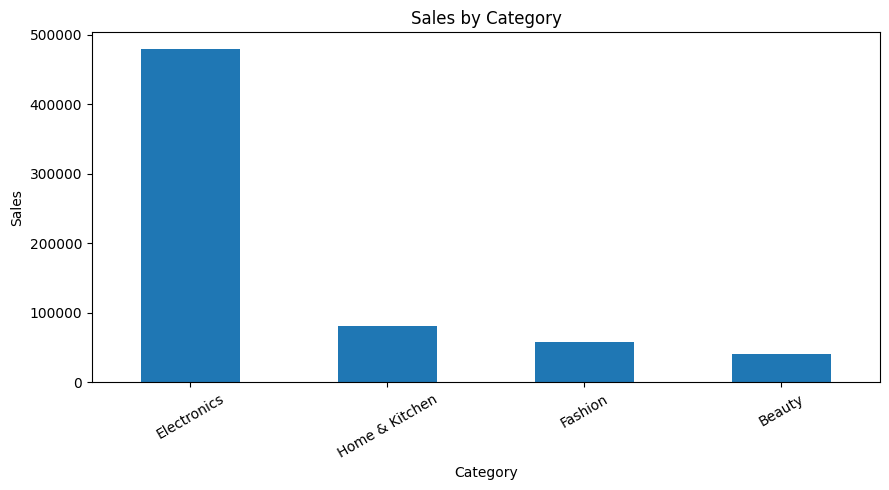


========== MONTHLY SALES ==========
Month_Number  Month    
1             January      106285
2             February      16720
3             March         34465
4             April         17615
5             May           68890
6             June          58150
7             July          59090
8             August        29260
9             September     69850
10            October       33150
11            November      79360
12            December      86390
Name: Sales, dtype: int64


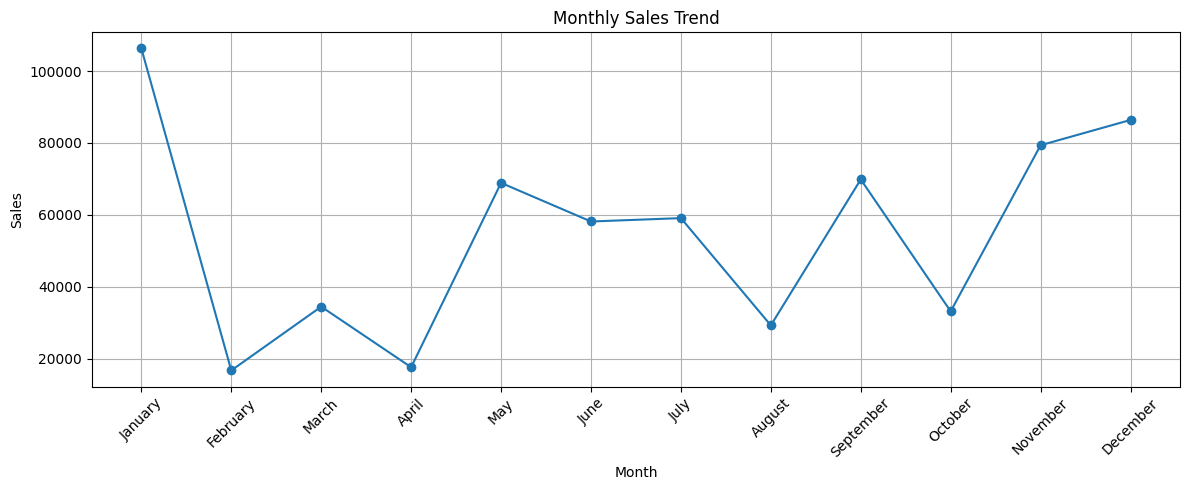


========== TOP PRODUCTS ==========
Product
Laptop           231750
Smartphone       146500
Tablet            64800
Office Chair      26925
Mixer Grinder     23450
Smart Watch       20300
Shoes             19950
Cookware Set      19475
Perfume           16960
Headphones        15900
Name: Sales, dtype: int64


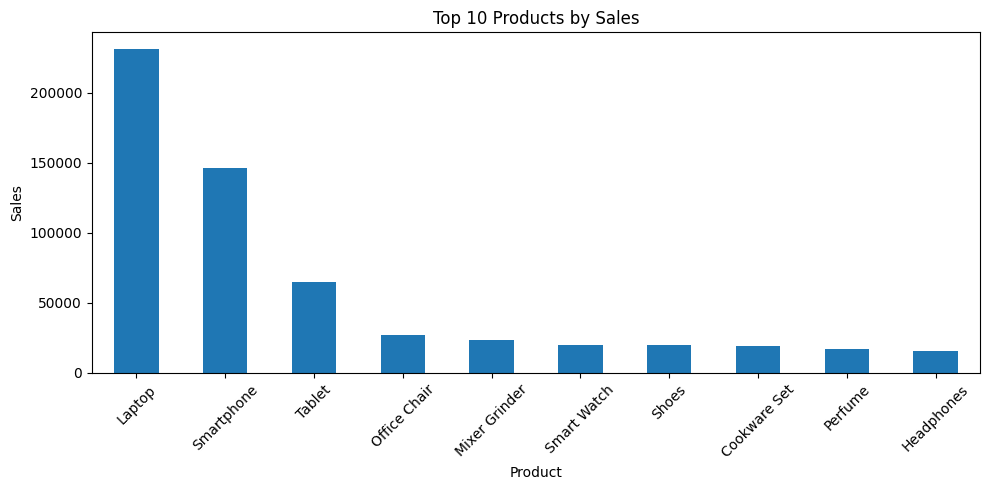


========== SALES BY STATE ==========
State
Maharashtra    286995
Gujarat        201485
Karnataka      129550
Rajasthan       22625
Delhi           18570
Name: Sales, dtype: int64


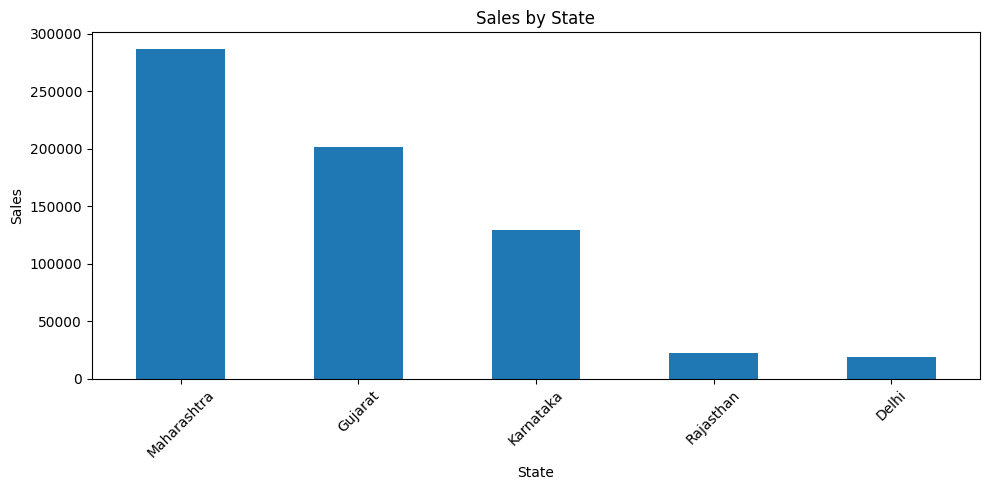


========== PAYMENT METHODS ==========
Payment_Mode
UPI                 24
Credit Card         11
Debit Card           6
Cash on Delivery     4
Net Banking          3
Name: count, dtype: int64


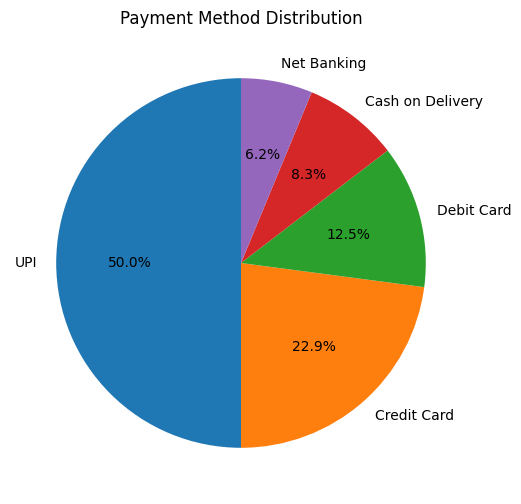


========== PROFIT BY CATEGORY ==========
Category
Electronics       72682.5
Home & Kitchen    16154.0
Fashion           11671.0
Beauty             8170.0
Name: Profit, dtype: float64


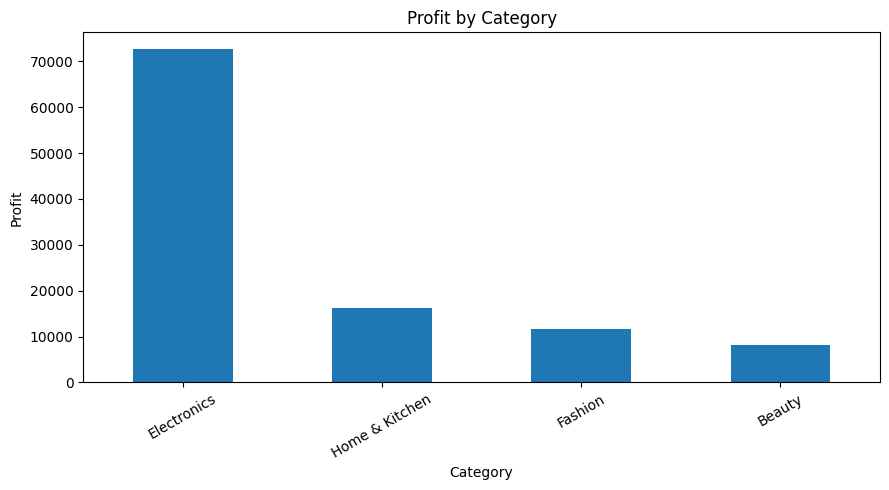


========== CORRELATION ==========
                  Quantity  Unit_Price  Discount_Percent     Sales    Profit
Quantity          1.000000   -0.513732         -0.192074 -0.443900 -0.445600
Unit_Price       -0.513732    1.000000          0.029353  0.946137  0.942083
Discount_Percent -0.192074    0.029353          1.000000  0.010012  0.000909
Sales            -0.443900    0.946137          0.010012  1.000000  0.998538
Profit           -0.445600    0.942083          0.000909  0.998538  1.000000


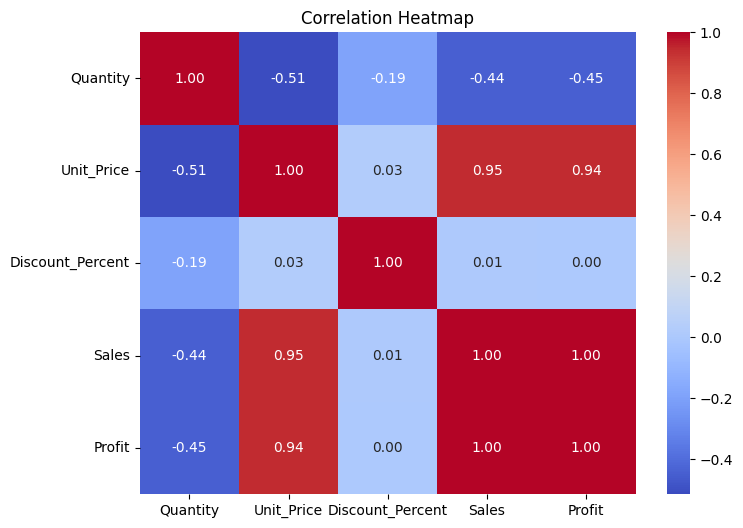

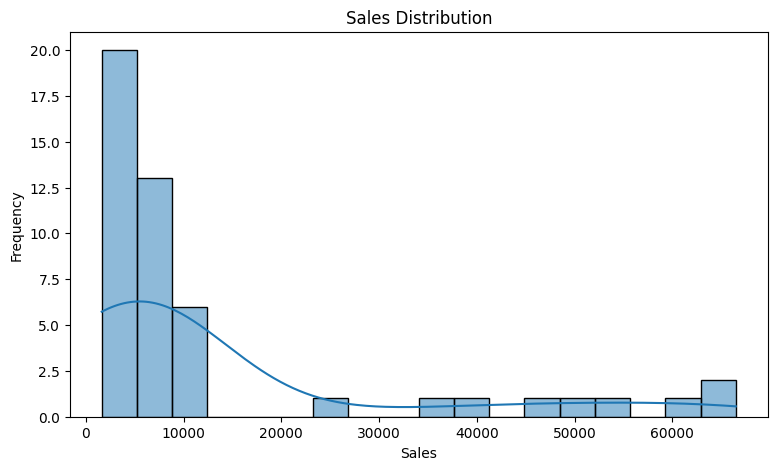


========== KEY FINDINGS ==========
Highest Sales Category: Electronics
Top Product: Laptop
Top State: Maharashtra
Most Used Payment Method: UPI
Total Sales: 659225
Total Profit: 108677.5

========== PROJECT COMPLETED ==========


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ecommerce_sales.csv")

print("========== E-COMMERCE SALES ANALYSIS ==========")

# Basic information
print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Data cleaning
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Discount_Percent"] = df["Discount_Percent"].fillna(
    df["Discount_Percent"].median()
)

df["Payment_Mode"] = df["Payment_Mode"].fillna(
    df["Payment_Mode"].mode()[0]
)

df = df.drop_duplicates()

# Basic statistics
print("\n========== STATISTICS ==========")

print("\nTotal Sales:",
      round(df["Sales"].sum(), 2))

print("Total Profit:",
      round(df["Profit"].sum(), 2))

print("Total Quantity Sold:",
      df["Quantity"].sum())

print("Average Order Value:",
      round(df["Sales"].mean(), 2))

# Category analysis
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY CATEGORY ==========")
print(category_sales)

# Category graph
plt.figure(figsize=(9, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Monthly analysis
df["Month"] = df["Order_Date"].dt.month_name()
df["Month_Number"] = df["Order_Date"].dt.month

monthly_sales = (
    df.groupby(["Month_Number", "Month"])["Sales"]
    .sum()
    .sort_index()
)

print("\n========== MONTHLY SALES ==========")
print(monthly_sales)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.get_level_values("Month"),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Top products
top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n========== TOP PRODUCTS ==========")
print(top_products)

plt.figure(figsize=(10, 5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# State analysis
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY STATE ==========")
print(state_sales)

plt.figure(figsize=(10, 5))

state_sales.plot(kind="bar")

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Payment analysis
payment_counts = df["Payment_Mode"].value_counts()

print("\n========== PAYMENT METHODS ==========")
print(payment_counts)

plt.figure(figsize=(8, 6))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

# Profit by category
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== PROFIT BY CATEGORY ==========")
print(category_profit)

plt.figure(figsize=(9, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Correlation
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Sales",
    "Profit"
]

correlation = df[numeric_columns].corr()

print("\n========== CORRELATION ==========")
print(correlation)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Sales distribution
plt.figure(figsize=(9, 5))

sns.histplot(df["Sales"], kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Final findings
print("\n========== KEY FINDINGS ==========")

print(
    "Highest Sales Category:",
    category_sales.idxmax()
)

print(
    "Top Product:",
    top_products.idxmax()
)

print(
    "Top State:",
    state_sales.idxmax()
)

print(
    "Most Used Payment Method:",
    payment_counts.idxmax()
)

print(
    "Total Sales:",
    round(df["Sales"].sum(), 2)
)

print(
    "Total Profit:",
    round(df["Profit"].sum(), 2)
)

print("\n========== PROJECT COMPLETED ==========")


========== MONTHLY PRODUCT SALES ==========

Available Products:
['Laptop' 'Smartphone' 'T-Shirt' 'Office Chair' 'Headphones' 'Shoes'
 'Mixer Grinder' 'Perfume' 'Tablet' 'Jeans' 'Cookware Set' 'Makeup Kit'
 'Smart Watch' 'Jacket' 'Bedsheet' 'Shampoo' 'Backpack' 'Table Lamp'
 'Moisturizer' 'Face Wash']

Monthly Sales for: laptop
Month_Number  Month    
1             January      49500
5             May          61750
9             September    54000
12            December     66500
Name: Sales, dtype: int64


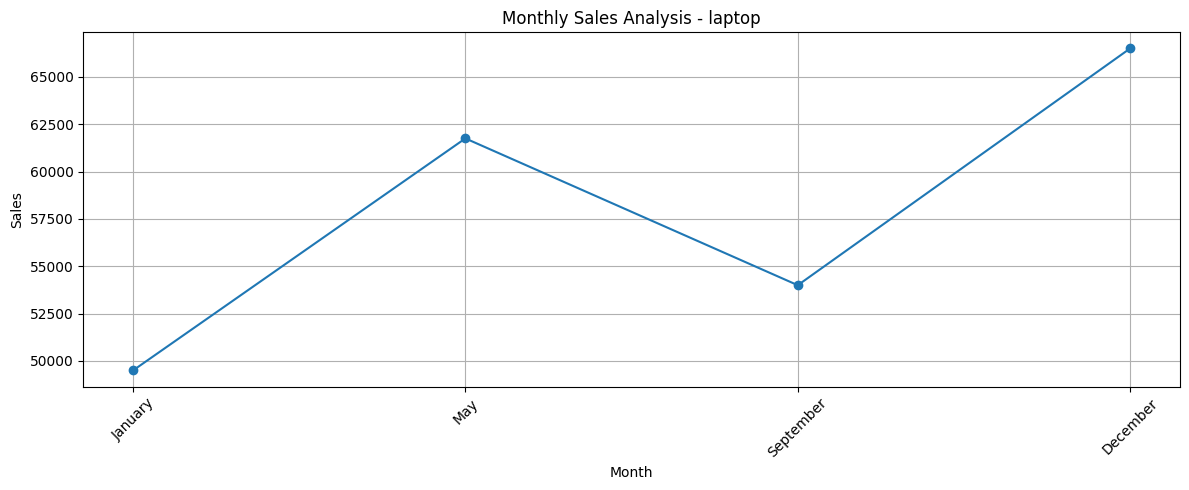

In [4]:
# Monthly Sales Analysis for Selected Product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ecommerce_sales.csv")

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("\n========== MONTHLY PRODUCT SALES ==========")

print("\nAvailable Products:")
print(df["Product"].unique())

# User enters product name
product_name = input("Enter Product Name: ")

# Filter selected product
product_data = df[
    df["Product"].str.lower() == product_name.lower()
]

if len(product_data) > 0:

    # Make a copy
    product_data = product_data.copy()

    # Extract month number
    product_data["Month_Number"] = product_data["Order_Date"].dt.month

    # Extract month name
    product_data["Month"] = product_data["Order_Date"].dt.month_name()

    # Calculate monthly sales
    monthly_sales = (
        product_data
        .groupby(["Month_Number", "Month"])["Sales"]
        .sum()
        .sort_index()
    )

    print("\nMonthly Sales for:", product_name)
    print(monthly_sales)

    # Graph
    plt.figure(figsize=(12, 5))

    plt.plot(
        monthly_sales.index.get_level_values("Month"),
        monthly_sales.values,
        marker="o"
    )

    plt.title(f"Monthly Sales Analysis - {product_name}")
    plt.xlabel("Month")
    plt.ylabel("Sales")

    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

else:
    print("Product not found!")

In [5]:
# Monthly Product Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ecommerce_sales.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("\n========== MONTHLY PRODUCT ANALYSIS ==========")

# Display available products
print("\nAvailable Products:")
print(df["Product"].unique())

# User input
product_name = input("\nEnter Product Name: ")

month_name = input(
    "Enter Month (e.g. January): "
)

# Convert month name to month number
try:
    month_number = pd.to_datetime(
        month_name,
        format="%B"
    ).month
except ValueError:
    print("Invalid month name!")
    month_number = None

if month_number is not None:

    # Filter product and month
    result = df[
        (df["Product"].str.lower() == product_name.lower())
        &
        (df["Order_Date"].dt.month == month_number)
    ]

    if len(result) > 0:

        # Analysis
        total_sales = result["Sales"].sum()
        total_profit = result["Profit"].sum()
        total_quantity = result["Quantity"].sum()
        total_orders = len(result)

        print("\n========== ANALYSIS RESULT ==========")

        print("Product:", product_name)
        print("Month:", month_name)

        print(
            "Total Orders:",
            total_orders
        )

        print(
            "Total Quantity Sold:",
            total_quantity
        )

        print(
            "Total Sales:",
            round(total_sales, 2)
        )

        print(
            "Total Profit:",
            round(total_profit, 2)
        )

        # Display records
        print("\n========== SALES RECORDS ==========")
        print(result)

        # Graph
        plt.figure(figsize=(10, 5))

        plt.bar(
            ["Sales", "Profit"],
            [total_sales, total_profit]
        )

        plt.title(
            f"{product_name} - {month_name} Analysis"
        )

        plt.ylabel("Amount")

        plt.tight_layout()
        plt.show()

    else:

        print(
            f"\nNo sales found for "
            f"{product_name} in {month_name}."
        )


========== MONTHLY PRODUCT ANALYSIS ==========

Available Products:
['Laptop' 'Smartphone' 'T-Shirt' 'Office Chair' 'Headphones' 'Shoes'
 'Mixer Grinder' 'Perfume' 'Tablet' 'Jeans' 'Cookware Set' 'Makeup Kit'
 'Smart Watch' 'Jacket' 'Bedsheet' 'Shampoo' 'Backpack' 'Table Lamp'
 'Moisturizer' 'Face Wash']

No sales found for  in .


========== E-COMMERCE SALES ANALYSIS ==========

========== DATASET INFORMATION ==========

First 5 Records:
  Order_ID  Order_Date Customer_ID       Product        Category Sub_Category  \
0   ORD001  2025-01-05    CUST1001        Laptop     Electronics    Computers   
1   ORD002  2025-01-08    CUST1002    Smartphone     Electronics      Mobiles   
2   ORD003  2025-01-15    CUST1003       T-Shirt         Fashion     Clothing   
3   ORD004  2025-01-21    CUST1004  Office Chair  Home & Kitchen    Furniture   
4   ORD005  2025-02-03    CUST1005    Headphones     Electronics  Accessories   

   Quantity  Unit_Price  Discount_Percent  Sales  Profit Payment_Mode  \
0         1       55000                10  49500  7425.0          UPI   
1         2       25000                 5  47500  7125.0  Credit Card   
2         3         800                10   2160   432.0          UPI   
3         1        7500                 5   7125  1425.0   Debit Card   
4         2        2500                

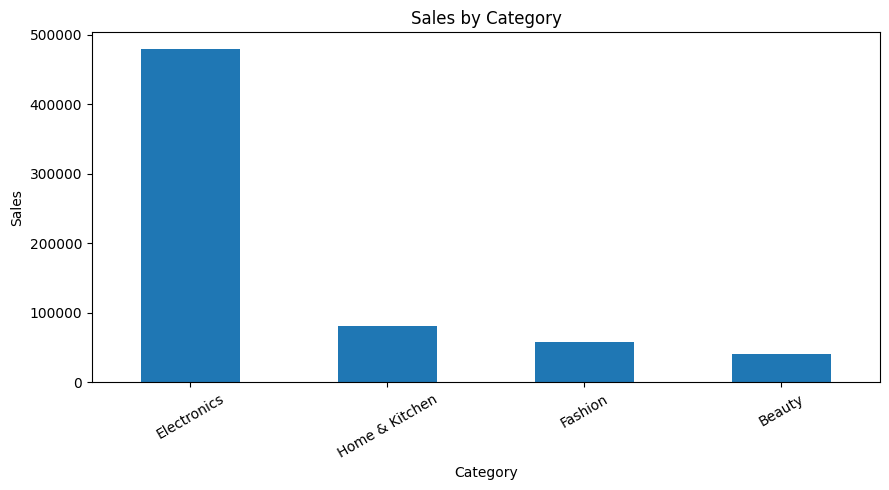


========== OVERALL MONTHLY SALES ==========
Month_Number  Month    
1             January      106285
2             February      16720
3             March         34465
4             April         17615
5             May           68890
6             June          58150
7             July          59090
8             August        29260
9             September     69850
10            October       33150
11            November      79360
12            December      86390
Name: Sales, dtype: int64


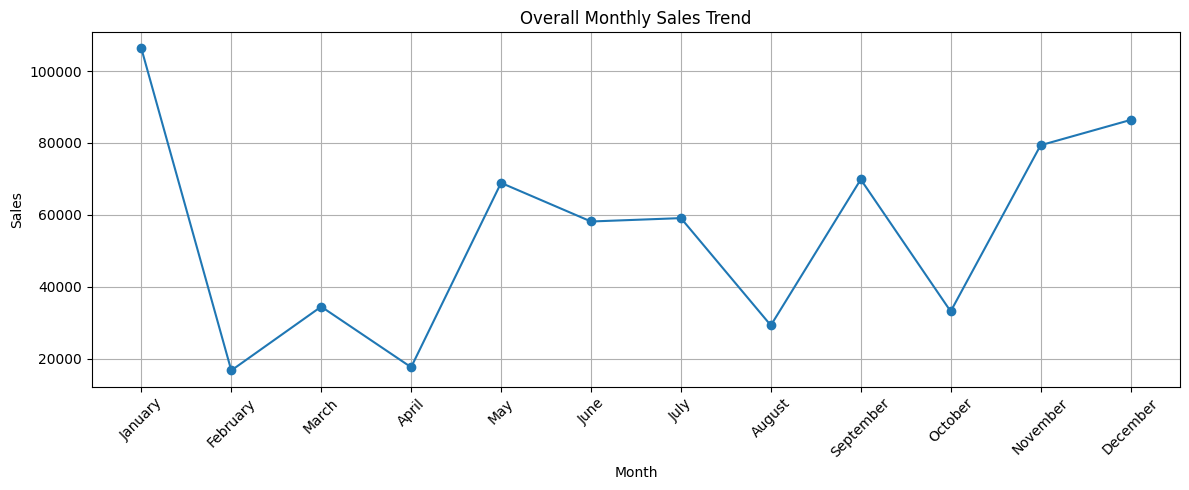


========== TOP 10 PRODUCTS ==========
Product
Laptop           231750
Smartphone       146500
Tablet            64800
Office Chair      26925
Mixer Grinder     23450
Smart Watch       20300
Shoes             19950
Cookware Set      19475
Perfume           16960
Headphones        15900
Name: Sales, dtype: int64


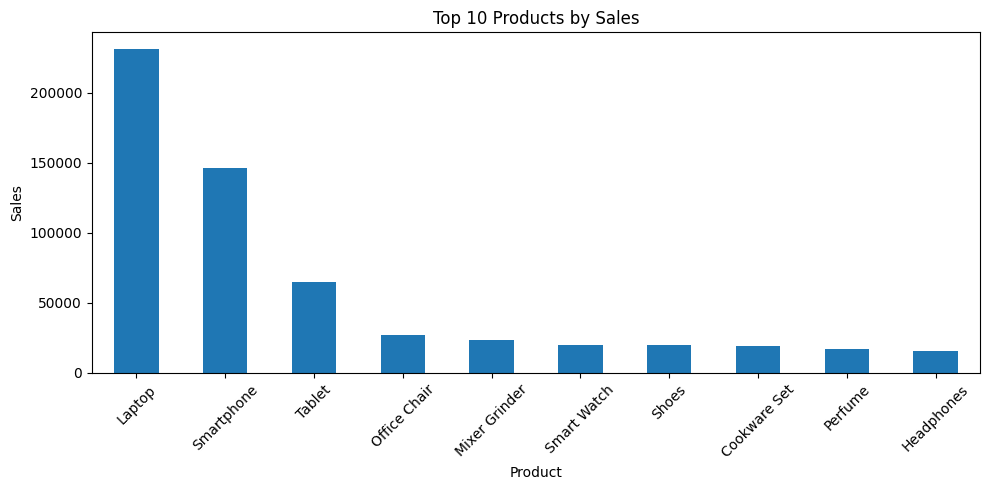


========== SALES BY STATE ==========
State
Maharashtra    286995
Gujarat        201485
Karnataka      129550
Rajasthan       22625
Delhi           18570
Name: Sales, dtype: int64


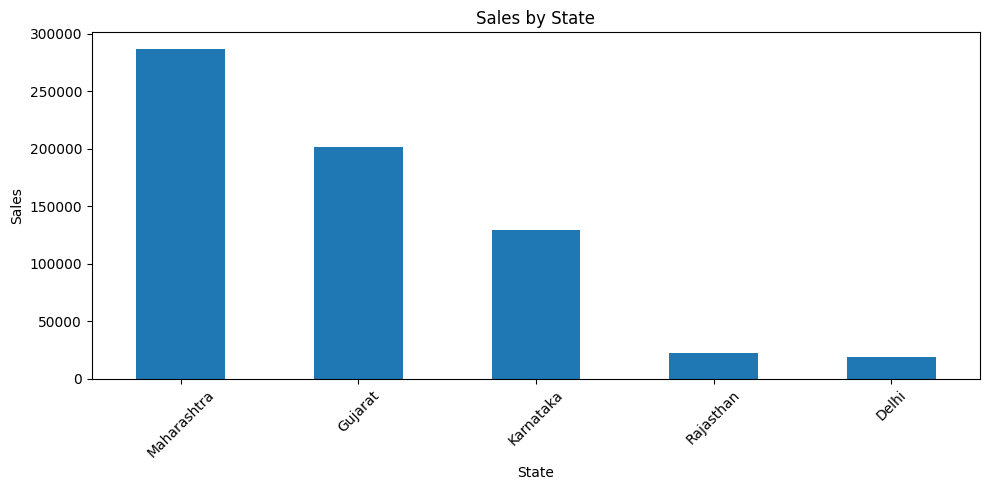


========== PAYMENT METHODS ==========
Payment_Mode
UPI                 24
Credit Card         11
Debit Card           6
Cash on Delivery     4
Net Banking          3
Name: count, dtype: int64


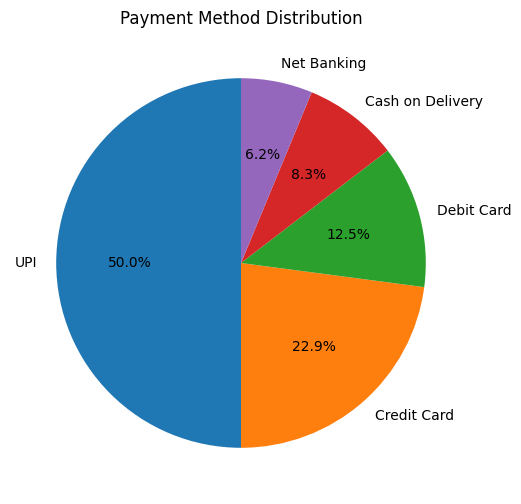


========== PROFIT BY CATEGORY ==========
Category
Electronics       72682.5
Home & Kitchen    16154.0
Fashion           11671.0
Beauty             8170.0
Name: Profit, dtype: float64


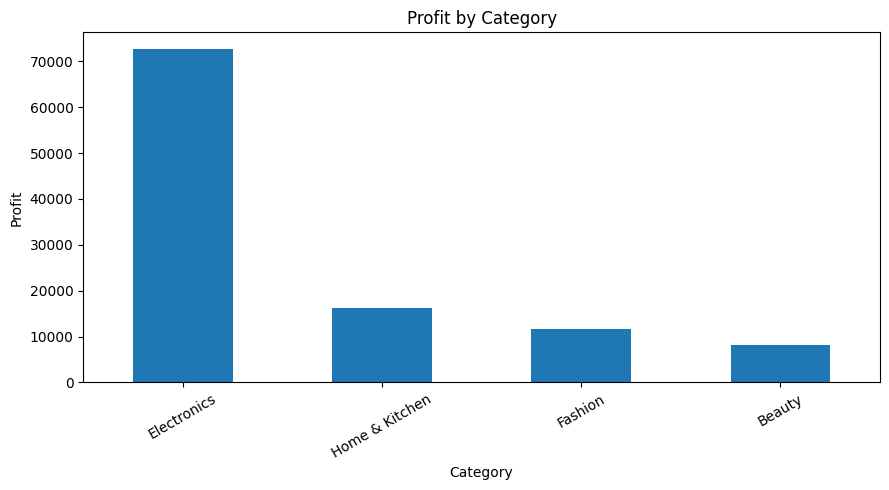


========== PRODUCT MONTHLY SALES ANALYSIS ==========

Available Products:
['Laptop' 'Smartphone' 'T-Shirt' 'Office Chair' 'Headphones' 'Shoes'
 'Mixer Grinder' 'Perfume' 'Tablet' 'Jeans' 'Cookware Set' 'Makeup Kit'
 'Smart Watch' 'Jacket' 'Bedsheet' 'Shampoo' 'Backpack' 'Table Lamp'
 'Moisturizer' 'Face Wash']


In [ ]:
# ============================================================
#              E-COMMERCE SALES ANALYSIS
#              Data Science Micro Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("ecommerce_sales.csv")

print("========== E-COMMERCE SALES ANALYSIS ==========")

# ------------------------------------------------------------
# 2. BASIC INFORMATION
# ------------------------------------------------------------

print("\n========== DATASET INFORMATION ==========")

print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# ------------------------------------------------------------
# 4. DATA CLEANING
# ------------------------------------------------------------

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Discount_Percent"] = df["Discount_Percent"].fillna(
    df["Discount_Percent"].median()
)

df["Payment_Mode"] = df["Payment_Mode"].fillna(
    df["Payment_Mode"].mode()[0]
)

df = df.drop_duplicates()

print("\nData Cleaning Completed Successfully!")

# ------------------------------------------------------------
# 5. BASIC STATISTICS
# ------------------------------------------------------------

print("\n========== BASIC STATISTICS ==========")

print("\nTotal Sales:",
      round(df["Sales"].sum(), 2))

print("Total Profit:",
      round(df["Profit"].sum(), 2))

print("Total Quantity Sold:",
      df["Quantity"].sum())

print("Average Order Value:",
      round(df["Sales"].mean(), 2))

print("\nDescriptive Statistics:")
print(
    df[
        [
            "Quantity",
            "Unit_Price",
            "Discount_Percent",
            "Sales",
            "Profit"
        ]
    ].describe()
)

# ------------------------------------------------------------
# 6. SALES BY CATEGORY
# ------------------------------------------------------------

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY CATEGORY ==========")
print(category_sales)

plt.figure(figsize=(9, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. OVERALL MONTHLY SALES
# ------------------------------------------------------------

df["Month_Number"] = df["Order_Date"].dt.month

df["Month"] = df["Order_Date"].dt.month_name()

monthly_sales = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Sales"]
    .sum()
    .sort_index()
)

print("\n========== OVERALL MONTHLY SALES ==========")
print(monthly_sales)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.get_level_values("Month"),
    monthly_sales.values,
    marker="o"
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. TOP 10 PRODUCTS
# ------------------------------------------------------------

top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n========== TOP 10 PRODUCTS ==========")
print(top_products)

plt.figure(figsize=(10, 5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. SALES BY STATE
# ------------------------------------------------------------

state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY STATE ==========")
print(state_sales)

plt.figure(figsize=(10, 5))

state_sales.plot(kind="bar")

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. PAYMENT METHOD ANALYSIS
# ------------------------------------------------------------

payment_counts = df["Payment_Mode"].value_counts()

print("\n========== PAYMENT METHODS ==========")
print(payment_counts)

plt.figure(figsize=(8, 6))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")

plt.show()

# ------------------------------------------------------------
# 11. PROFIT BY CATEGORY
# ------------------------------------------------------------

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== PROFIT BY CATEGORY ==========")
print(category_profit)

plt.figure(figsize=(9, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. CORRELATION ANALYSIS
# ------------------------------------------------------------

# numeric_columns = [
#     "Quantity",
#     "Unit_Price",
#     "Discount_Percent",
#     "Sales",
#     "Profit"
# ]

# correlation = df[numeric_columns].corr()

# print("\n========== CORRELATION ANALYSIS ==========")
# print(correlation)

# plt.figure(figsize=(8, 6))

# sns.heatmap(
#     correlation,
#     annot=True,
#     cmap="coolwarm",
#     fmt=".2f"
# )

# plt.title("Correlation Heatmap")

# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------
# # 13. SALES DISTRIBUTION
# # ------------------------------------------------------------

# plt.figure(figsize=(9, 5))

# sns.histplot(
#     df["Sales"],
#     kde=True
# )

# plt.title("Sales Distribution")
# plt.xlabel("Sales")
# plt.ylabel("Frequency")

# plt.tight_layout()
# plt.show()

# ------------------------------------------------------------
# 14. SELECTED PRODUCT MONTHLY SALES
# ------------------------------------------------------------

print("\n========== PRODUCT MONTHLY SALES ANALYSIS ==========")

print("\nAvailable Products:")

print(df["Product"].unique())

product_name = input(
    "\nEnter Product Name for Monthly Analysis: "
).strip()

# Find selected product
product_data = df[
    df["Product"].str.strip().str.lower()
    == product_name.lower()
]

if len(product_data) > 0:

    product_data = product_data.copy()

    # Get month number
    product_data["Month_Number"] = (
        product_data["Order_Date"].dt.month
    )

    # Get month name
    product_data["Month"] = (
        product_data["Order_Date"].dt.month_name()
    )

    # Calculate monthly sales
    monthly_product_sales = (
        product_data
        .groupby(
            ["Month_Number", "Month"]
        )["Sales"]
        .sum()
        .sort_index()
    )

    print(
        "\nMonthly Sales for:",
        product_name
    )

    print(monthly_product_sales)

    # Graph
    plt.figure(figsize=(12, 5))

    plt.plot(
        monthly_product_sales
        .index
        .get_level_values("Month"),
        monthly_product_sales.values,
        marker="o"
    )

    plt.title(
        f"Monthly Sales Analysis - {product_name}"
    )

    plt.xlabel("Month")
    plt.ylabel("Sales")

    plt.xticks(rotation=45)

    plt.grid(True)

    plt.tight_layout()

    plt.show()

else:

    print("\nProduct not found!")

# ------------------------------------------------------------
# 15. DISCOUNT ANALYSIS
# ------------------------------------------------------------

# print("\n========== DISCOUNT ANALYSIS ==========")

# discount_analysis = (
#     df.groupby("Discount_Percent")["Sales"]
#     .sum()
#     .sort_index()
# )

# print(discount_analysis)

# plt.figure(figsize=(10, 5))

# plt.plot(
#     discount_analysis.index,
#     discount_analysis.values,
#     marker="o"
# )

# plt.title("Discount Percentage vs Sales")
# plt.xlabel("Discount Percentage")
# plt.ylabel("Sales")

# plt.grid(True)
# plt.tight_layout()
# plt.show()

# ------------------------------------------------------------
# 16. KEY FINDINGS
# ------------------------------------------------------------

print("\n========== KEY FINDINGS ==========")

print(
    "Highest Sales Category:",
    category_sales.idxmax()
)

print(
    "Top Product:",
    top_products.idxmax()
)

print(
    "Top State:",
    state_sales.idxmax()
)

print(
    "Most Used Payment Method:",
    payment_counts.idxmax()
)

print(
    "Total Sales:",
    round(df["Sales"].sum(), 2)
)

print(
    "Total Profit:",
    round(df["Profit"].sum(), 2)
)

print("\n========== PROJECT COMPLETED ==========")



             E-COMMERCE SALES ANALYSIS

1.  Display First 5 Records
2.  Dataset Information
3.  Missing Values
4.  Basic Statistics
5.  Sales by Category
6.  Overall Monthly Sales
7.  Top 10 Products
8.  Sales by State
9.  Payment Method Analysis
10. Profit by Category
11. Product Monthly Sales Analysis
12. Key Findings
13. Exit



========== PRODUCT MONTHLY SALES ==========

Available Products:
- Laptop
- Smartphone
- T-Shirt
- Office Chair
- Headphones
- Shoes
- Mixer Grinder
- Perfume
- Tablet
- Jeans
- Cookware Set
- Makeup Kit
- Smart Watch
- Jacket
- Bedsheet
- Shampoo
- Backpack
- Table Lamp
- Moisturizer
- Face Wash

Monthly Sales for: Smartphone
Month_Number  Month   
1             January     47500
6             June        36000
11            November    63000
Name: Sales, dtype: int64


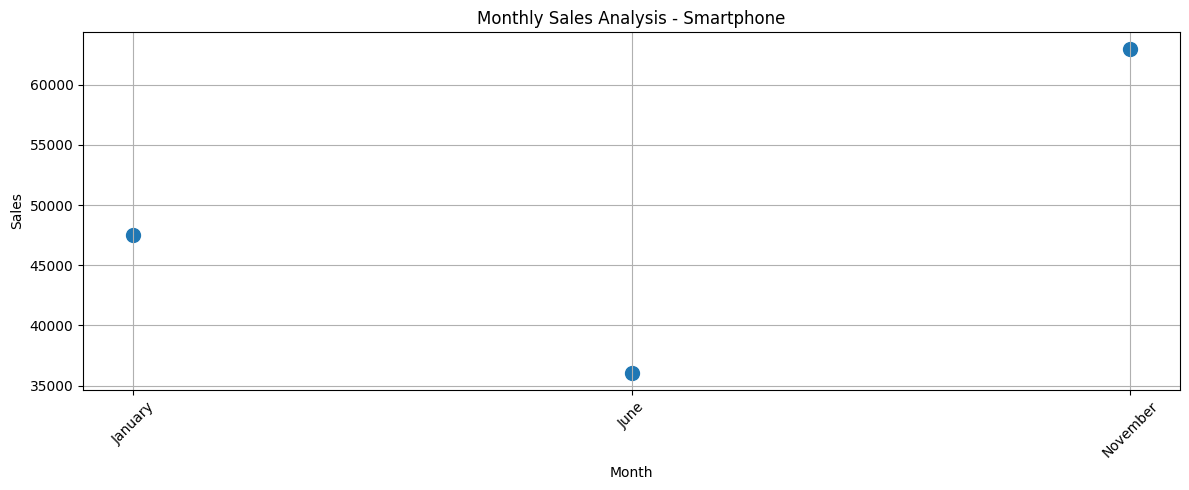



             E-COMMERCE SALES ANALYSIS

1.  Display First 5 Records
2.  Dataset Information
3.  Missing Values
4.  Basic Statistics
5.  Sales by Category
6.  Overall Monthly Sales
7.  Top 10 Products
8.  Sales by State
9.  Payment Method Analysis
10. Profit by Category
11. Product Monthly Sales Analysis
12. Key Findings
13. Exit

========== PROJECT COMPLETED ==========
Thank you for using E-Commerce Sales Analysis!


In [ ]:
# ============================================================
#              E-COMMERCE SALES ANALYSIS
#              Data Science Micro Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("ecommerce_sales.csv")

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

df["Discount_Percent"] = df["Discount_Percent"].fillna(
    df["Discount_Percent"].median()
)

df["Payment_Mode"] = df["Payment_Mode"].fillna(
    df["Payment_Mode"].mode()[0]
)

df = df.drop_duplicates()

# ------------------------------------------------------------
# 3. MAIN MENU
# ------------------------------------------------------------

while True:

    print("\n")
    print("=" * 60)
    print("             E-COMMERCE SALES ANALYSIS")
    print("=" * 60)

    print("\n1.  Display First 5 Records")
    print("2.  Dataset Information")
    print("3.  Missing Values")
    print("4.  Basic Statistics")
    print("5.  Sales by Category")
    print("6.  Overall Monthly Sales")
    print("7.  Top 10 Products")
    print("8.  Sales by State")
    print("9.  Payment Method Analysis")
    print("10. Profit by Category")
    print("11. Product Monthly Sales Analysis")
    print("12. Key Findings")
    print("13. Exit")

    choice = input("\nEnter your choice: ")

    # --------------------------------------------------------
    # 1. FIRST 5 RECORDS
    # --------------------------------------------------------

    if choice == "1":

        print("\n========== FIRST 5 RECORDS ==========")
        print(df.head())

    # --------------------------------------------------------
    # 2. DATASET INFORMATION
    # --------------------------------------------------------

    elif choice == "2":

        print("\n========== DATASET INFORMATION ==========")

        print("\nDataset Shape:")
        print(df.shape)

        print("\nData Types:")
        print(df.dtypes)

        print("\nDataset Information:")
        df.info()

    # --------------------------------------------------------
    # 3. MISSING VALUES
    # --------------------------------------------------------

    elif choice == "3":

        print("\n========== MISSING VALUES ==========")

        print(df.isnull().sum())

    # --------------------------------------------------------
    # 4. BASIC STATISTICS
    # --------------------------------------------------------

    elif choice == "4":

        print("\n========== BASIC STATISTICS ==========")

        print("Total Sales:",
              round(df["Sales"].sum(), 2))

        print("Total Profit:",
              round(df["Profit"].sum(), 2))

        print("Total Quantity Sold:",
              df["Quantity"].sum())

        print("Average Order Value:",
              round(df["Sales"].mean(), 2))

        print("\nDescriptive Statistics:")
        print(df[
            ["Quantity",
             "Unit_Price",
             "Discount_Percent",
             "Sales",
             "Profit"]
        ].describe())

    # --------------------------------------------------------
    # 5. SALES BY CATEGORY
    # --------------------------------------------------------

    elif choice == "5":

        category_sales = (
            df.groupby("Category")["Sales"]
            .sum()
            .sort_values(ascending=False)
        )

        print("\n========== SALES BY CATEGORY ==========")
        print(category_sales)

        plt.figure(figsize=(9, 5))

        category_sales.plot(kind="bar")

        plt.title("Sales by Category")
        plt.xlabel("Category")
        plt.ylabel("Sales")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 6. OVERALL MONTHLY SALES
    # --------------------------------------------------------

    elif choice == "6":

        df["Month_Number"] = df["Order_Date"].dt.month
        df["Month"] = df["Order_Date"].dt.month_name()

        monthly_sales = (
            df.groupby(
                ["Month_Number", "Month"]
            )["Sales"]
            .sum()
            .sort_index()
        )

        print("\n========== OVERALL MONTHLY SALES ==========")
        print(monthly_sales)

        plt.figure(figsize=(12, 5))

        plt.plot(
            monthly_sales.index.get_level_values("Month"),
            monthly_sales.values,
            marker="o"
        )

        plt.title("Overall Monthly Sales Trend")
        plt.xlabel("Month")
        plt.ylabel("Sales")

        plt.xticks(rotation=45)
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 7. TOP 10 PRODUCTS
    # --------------------------------------------------------

    elif choice == "7":

        top_products = (
            df.groupby("Product")["Sales"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )

        print("\n========== TOP 10 PRODUCTS ==========")
        print(top_products)

        plt.figure(figsize=(10, 5))

        top_products.plot(kind="bar")

        plt.title("Top 10 Products by Sales")
        plt.xlabel("Product")
        plt.ylabel("Sales")

        # plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 8. SALES BY STATE
    # --------------------------------------------------------

    elif choice == "8":

        state_sales = (
            df.groupby("State")["Sales"]
            .sum()
            .sort_values(ascending=False)
        )

        print("\n========== SALES BY STATE ==========")
        print(state_sales)

        plt.figure(figsize=(10, 5))

        state_sales.plot(kind="bar")

        plt.title("Sales by State")
        plt.xlabel("State")
        plt.ylabel("Sales")

        # plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 9. PAYMENT METHOD ANALYSIS
    # --------------------------------------------------------

    elif choice == "9":

        payment_counts = df["Payment_Mode"].value_counts()

        print("\n========== PAYMENT METHODS ==========")
        print(payment_counts)

        plt.figure(figsize=(8, 6))

        plt.pie(
            payment_counts.values,
            labels=payment_counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title("Payment Method Distribution")

        plt.show()

    # --------------------------------------------------------
    # 10. PROFIT BY CATEGORY
    # --------------------------------------------------------

    elif choice == "10":

        category_profit = (
            df.groupby("Category")["Profit"]
            .sum()
            .sort_values(ascending=False)
        )

        print("\n========== PROFIT BY CATEGORY ==========")
        print(category_profit)

        plt.figure(figsize=(9, 5))

        category_profit.plot(kind="bar")

        plt.title("Profit by Category")
        plt.xlabel("Category")
        plt.ylabel("Profit")

        # plt.xticks(rotation=30)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 11. PRODUCT MONTHLY SALES ANALYSIS
    # --------------------------------------------------------

    elif choice == "11":

        print("\n========== PRODUCT MONTHLY SALES ==========")

        print("\nAvailable Products:")

        for product in df["Product"].unique():
            print("-", product)

        product_name = input(
            "\nEnter Product Name: "
        ).strip()

        product_data = df[
            df["Product"].str.strip().str.lower()
            == product_name.lower()
        ]

        if len(product_data) > 0:

            product_data = product_data.copy()

            product_data["Month_Number"] = (
                product_data["Order_Date"].dt.month
            )

            product_data["Month"] = (
                product_data["Order_Date"].dt.month_name()
            )

            monthly_product_sales = (
                product_data
                .groupby(
                    ["Month_Number", "Month"]
                )["Sales"]
                .sum()
                .sort_index()
            )

            print(
                "\nMonthly Sales for:",
                product_name
            )

            print(monthly_product_sales)

            # Graph
            # Scatter Plot
            plt.figure(figsize=(12, 5))

            plt.scatter(
                monthly_product_sales.index.get_level_values("Month"),
                monthly_product_sales.values,
                s=100
            )

            plt.title(
                f"Monthly Sales Analysis - {product_name}"
            )

            plt.xlabel("Month")
            plt.ylabel("Sales")

            plt.xticks(rotation=45)

            plt.grid(True)

            plt.tight_layout()

            plt.show()

        else:

            print("\nProduct not found!")

    # --------------------------------------------------------
    # 12. KEY FINDINGS
    # --------------------------------------------------------

    elif choice == "12":

        category_sales = (
            df.groupby("Category")["Sales"]
            .sum()
            .sort_values(ascending=False)
        )

        top_products = (
            df.groupby("Product")["Sales"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )

        state_sales = (
            df.groupby("State")["Sales"]
            .sum()
            .sort_values(ascending=False)
        )

        payment_counts = (
            df["Payment_Mode"]
            .value_counts()
        )

        print("\n========== KEY FINDINGS ==========")

        print(
            "Highest Sales Category:",
            category_sales.idxmax()
        )

        print(
            "Top Product:",
            top_products.idxmax()
        )

        print(
            "Top State:",
            state_sales.idxmax()
        )

        print(
            "Most Used Payment Method:",
            payment_counts.idxmax()
        )

        print(
            "Total Sales:",
            round(df["Sales"].sum(), 2)
        )

        print(
            "Total Profit:",
            round(df["Profit"].sum(), 2)
        )

    # --------------------------------------------------------
    # 13. EXIT
    # --------------------------------------------------------

    elif choice == "13":

        print("\n========== PROJECT COMPLETED ==========")
        print("Thank you for using E-Commerce Sales Analysis!")

        break

    # --------------------------------------------------------
    # INVALID CHOICE
    # --------------------------------------------------------

    else:

        print("\nInvalid choice!")
        print("Please enter a number between 1 and 15.")